### Import Functions and Initialize Constants

In [1]:
# ==== IMPORT FUNCTIONS ====
from __future__ import annotations

# ==== Silence Warnings ====
import logging
import warnings

from transformers import logging as hf_logging

# from hidden.Demo.Inference_LJSpeech import text_aligner

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="huggingface_hub.file_download"
)

hf_logging.set_verbosity_error()

logging.getLogger("torch.distributed.elastic.multiprocessing.redirects").setLevel(logging.ERROR)
logging.getLogger('phonemizer').setLevel(logging.ERROR)

# === Standard Library ===
import datetime
import os

# === Third-Party Libraries ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jiwer
import torch.nn.functional as F

import librosa
from pesq import pesq

import re

import torch

import soundfile as sf

from huggingface_hub import hf_hub_download

from sentence_transformers import SentenceTransformer, util
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Wav2Vec2Model, Wav2Vec2Processor

import IPython.display as ipd

# === Pymoo Optimization Framework ===
# from pymoo.algorithms.base.genetic import GeneticAlgorithm
from pymoo.algorithms.moo.nsga2 import NSGA2
# from pymoo.core.evaluator import Evaluator
# from pymoo.core.population import Population
# from pymoo.core.problem import Problem
# from pymoo.core.termination import NoTermination
# from pymoo.operators.crossover.sbx import SBX
# from pymoo.operators.mutation.pm import PM
# from pymoo.operators.sampling.rnd import FloatRandomSampling
# from pymoo.problems.static import StaticProblem

# === From Files ===
from _helper import addNumbersPattern, adjustInterpolationVector, AttackMode, FitnessObjective, _extend_to_size
from _pymoo_optimizer import PymooOptimizer
from _styletts2 import StyleTTS2
from _asr_model import AutomaticSpeechRecognitionModel

# === Notification Assistant ===
from dotenv import load_dotenv
import requests

load_dotenv()
WHATSAPP_PHONE_NUMBER = os.getenv("WHATSAPP_PHONE_NUMBER")
WHATSAPP_API_KEY = os.getenv("WHATSAPP_API_KEY")

%cd ..


# ==== Set Constants ====
OBJECTIVE_ORDER: list[FitnessObjective] = [

    # ==== Increase Naturalness ====
    FitnessObjective.PHONEME_COUNT,
    FitnessObjective.AVG_LOGPROB,
    FitnessObjective.UTMOS,
    FitnessObjective.PPL,
    FitnessObjective.PESQ,

    # ==== Interpolation Vector Restrictions ====
    FitnessObjective.L1,
    FitnessObjective.L2,

    # ==== Optimize Text Towards Target ====
    FitnessObjective.WER_TARGET,
    FitnessObjective.SBERT_TARGET,
    FitnessObjective.TEXT_EMB_TARGET,

    # ==== Optimize Text Away From Ground-Truth ====
    FitnessObjective.WER_GT,
    FitnessObjective.SBERT_GT,
    FitnessObjective.TEXT_EMB_GT,

    # ==== Optimize Audio Similarity ====
    FitnessObjective.WAV2VEC_SIMILAR,
    FitnessObjective.WAV2VEC_DIFFERENT,
    FitnessObjective.WAV2VEC_ASR,
]

C:\Users\Yanis Wilbrand\PycharmProjects\StyleTTS2


### Initializes Variables

In [2]:
ACTIVE_OBJECTIVES: set[FitnessObjective] = {
    FitnessObjective.PESQ,
    FitnessObjective.WER_GT,
}

diffusion_steps = 5
embedding_scale = 1

mode = AttackMode.TARGETED
subspace_optimization = False

iv_scalar = 0.5

pop_size = 100
num_generations = 150

size_per_phoneme = 1

text_gt = "I think the NFL is lame and boring"
text_target = "The Seattle Seahawks are the best Team in the world"

device = 'cuda' if torch.cuda.is_available() else 'cpu'
noise = torch.randn(1, 1, 256).to(device)
random_matrix = np.random.rand(size_per_phoneme, 512)
# Alternatives: rng.random((512, s)), np.random.randn(512, s)

random_matrix = torch.from_numpy(random_matrix).to(device).float() # For Matrix Multiplication

text_message = "Iteration finished, check results!"
notify = True

### Load Models

In [3]:
# ==== Required Models ====

# 1) Load StyleTTS2
tts_model = StyleTTS2()
tts_model.load_models()  # builds self.model and loads self.params
tts_model.load_checkpoints()  # puts params into self.model
tts_model.sample_diffusion()  # builds self.sampler

# 2) Extract Embedding Vectors
if mode is AttackMode.TARGETED :
    # Text -> Tokens, while adding Tokens if necessary
    tokens_gt, tokens_target = addNumbersPattern(
        tts_model.preprocessText(text_gt),
        tts_model.preprocessText(text_target),
        [16, 4]
    )

    h_text_gt, h_bert_raw_gt, h_bert_gt, input_lengths, text_mask = tts_model.extract_embeddings(tokens_gt)
    h_text_target, h_bert_raw_target, h_bert_target, _, _ = tts_model.extract_embeddings(tokens_target)

else:
    tokens_gt = tts_model.preprocessText(text_gt)

    h_text_gt, h_bert_raw_gt, h_bert_gt, input_lengths, text_mask = tts_model.extract_embeddings(tokens_gt)

    h_text_target = torch.randn_like(h_text_gt)
    h_text_target /= h_text_target.norm()

    h_bert_raw_target = torch.randn_like(h_bert_raw_gt)
    h_bert_raw_target /= h_bert_raw_target.norm()

    h_bert_target = torch.randn_like(h_bert_gt)
    h_bert_target /= h_bert_target.norm()

# 3) Generate Style Vector
style_vector_acoustic, style_vector_prosodic = tts_model.computeStyleVector(noise, h_bert_raw_gt, embedding_scale, diffusion_steps)

# 4) Run rest of inference for ground-truth and target
audio_gt = tts_model.inference_after_interpolation(input_lengths, text_mask, h_bert_gt, h_text_gt, style_vector_acoustic, style_vector_prosodic)
audio_target = tts_model.inference_after_interpolation(input_lengths, text_mask, h_bert_target, h_text_target, style_vector_acoustic, style_vector_prosodic)

# 5) Load ASR Model
asr_model = AutomaticSpeechRecognitionModel("tiny", device=device)

# 6) Load Optimizer
phoneme_count = input_lengths.detach().cpu().item()

optimizer = PymooOptimizer(
    bounds=(0, 1),
    algorithm=NSGA2,
    algo_params={
        "pop_size": pop_size,
    },
    num_objectives=ACTIVE_OBJECTIVES.__len__(),
    solution_shape=(phoneme_count, size_per_phoneme),
)

# ==== Conditional Models ====

if FitnessObjective.TEXT_EMB_TARGET in ACTIVE_OBJECTIVES or FitnessObjective.TEXT_EMB_GT in ACTIVE_OBJECTIVES:
    embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=device)
    embedding_model.eval()

    text_embedding_gt = embedding_model.encode(text_gt, convert_to_tensor=True, normalize_embeddings=True)

    if mode is AttackMode.TARGETED:
        text_embedding_target = embedding_model.encode(text_target, convert_to_tensor=True, normalize_embeddings=True)

    elif mode is AttackMode.NOISE_UNTARGETED:
        # Create random noise embedding of same dimension
        text_embedding_target = torch.randn_like(text_embedding_gt)
        text_embedding_target /= text_embedding_target.norm()

    elif mode is AttackMode.UNTARGETED:
        # No target direction needed
        text_embedding_target = None

if FitnessObjective.UTMOS in ACTIVE_OBJECTIVES:
    utmos_model = torch.jit.load(
        hf_hub_download(
            repo_id="balacoon/utmos",
            filename="utmos.jit",
            repo_type="model",
            local_dir="./",
        ),
        map_location=device
    )
    utmos_model.eval()

if FitnessObjective.SBERT_GT in ACTIVE_OBJECTIVES or FitnessObjective.SBERT_TARGET in ACTIVE_OBJECTIVES:
    sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
    sbert_model.eval()

    s_bert_embedding_gt = sbert_model.encode(text_gt, convert_to_tensor=True, normalize_embeddings=True)

    if mode is AttackMode.TARGETED:
        s_bert_embedding_target = sbert_model.encode(text_target, convert_to_tensor=True, normalize_embeddings=True)

    elif mode is AttackMode.NOISE_UNTARGETED:
        # Create random noise embedding of same dimension
        s_bert_embedding_target = torch.randn_like(s_bert_embedding_gt)
        s_bert_embedding_target /= s_bert_embedding_target.norm()

    elif mode is AttackMode.UNTARGETED:
        # No target direction needed
        s_bert_embedding_target = None

if FitnessObjective.WER_TARGET in ACTIVE_OBJECTIVES or FitnessObjective.WER_GT in ACTIVE_OBJECTIVES:
    wer_transformations = jiwer.Compose([
        jiwer.ExpandCommonEnglishContractions(),
        jiwer.RemoveEmptyStrings(),
        jiwer.ToLowerCase(),
        jiwer.RemoveMultipleSpaces(),
        jiwer.Strip(),
        jiwer.RemovePunctuation(),
        jiwer.ReduceToListOfListOfWords(),
    ])

if FitnessObjective.PPL in ACTIVE_OBJECTIVES:
    perplexity_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    perplexity_model.eval()
    perplexity_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

if FitnessObjective.WAV2VEC_SIMILAR in ACTIVE_OBJECTIVES or FitnessObjective.WAV2VEC_DIFFERENT in ACTIVE_OBJECTIVES or FitnessObjective.WAV2VEC_ASR in ACTIVE_OBJECTIVES:
    wav2vec_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-960h-lv60-self")
    wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-large-960h-lv60-self").to(device)
    wav2vec_model.eval()

    with torch.no_grad():
        wav2vec_embedding_gt = torch.mean(wav2vec_model(**wav2vec_processor(audio_gt, return_tensors="pt", sampling_rate=16000).to(device)).last_hidden_state, dim=1)

        if mode is AttackMode.TARGETED:
            wav2vec_embedding_target = torch.mean(wav2vec_model(**wav2vec_processor(audio_target, return_tensors="pt", sampling_rate=16000).to(device)).last_hidden_state, dim=1)

        elif mode is AttackMode.NOISE_UNTARGETED:
            # Create random noise embedding of same dimension
            wav2vec_embedding_target = torch.randn_like(wav2vec_embedding_gt)
            wav2vec_embedding_target /= wav2vec_embedding_target.norm()

        elif mode is AttackMode.UNTARGETED:
            # No target direction needed
            wav2vec_embedding_target = None

### Loop

In [ ]:
# 1. Initialize a list to hold all records
fitness_history = []
mean_model = []

for gen in range(num_generations):

    # Dict: FitnessObjective -> list of scores for this generation
    gen_scores: dict[FitnessObjective, list[float]] = {
        obj: [] for obj in ACTIVE_OBJECTIVES
    }

    population_vectors = optimizer.get_x_current()  # shape: (pop_size, *solution_shape)

    print(f"=== Generation {gen} ===")

    for j, interpolation_vector in enumerate(population_vectors):

        # Ensure vector is on the correct device
        IV = torch.from_numpy(interpolation_vector).to(device).float()
        interpolation_vector = adjustInterpolationVector(IV, random_matrix, subspace_optimization)

        # Interpolate Values depending on AttackMode
        if mode is AttackMode.NOISE_UNTARGETED or mode is AttackMode.TARGETED:
            h_text_mixed = (1.0 - interpolation_vector) * h_text_gt + interpolation_vector * h_text_target
        else:
            if h_text_gt.shape != interpolation_vector.shape:
                raise ValueError("AttackMode.UNTARGETED requires h_text_gt and interpolation_vector to be of same shape.")
            h_text_mixed = h_text_gt + iv_scalar * interpolation_vector

        h_bert_mixed = h_bert_gt

        # Inference
        audio_mixed = tts_model.inference_after_interpolation(
            input_lengths,
            text_mask,
            h_bert_mixed,
            h_text_mixed,
            style_vector_acoustic,
            style_vector_prosodic
        )

        # ASR Analysis
        asr_result, asr_logprob = asr_model.analyzeAudio(audio_mixed)
        asr_text = asr_result["text"]

        # === FORCE ENGLISH ONLY ===
        # Keep only A-Z, a-z, and spaces. Remove everything else.
        clean_text = re.sub(r'[^a-zA-Z\s]', '', asr_text).strip()

        # If the text was mostly garbage and is now empty:
        if len(clean_text) < 2:
            # Penalize heavily and skip
            val = 10.0
            for obj in ACTIVE_OBJECTIVES:
                gen_scores[obj].append(val)
                current_ind_scores[obj] = val

            record = {"Generation": gen, "Individual_ID": j}
            record.update(current_ind_scores)
            fitness_history.append(record)
            continue

        # Update the text for the rest of the pipeline
        asr_text = clean_text

        # Initialize dictionary using Enum keys type hint
        current_ind_scores: dict[FitnessObjective, float] = {}


        # ==== Increase Naturalness ====
        if FitnessObjective.PHONEME_COUNT in ACTIVE_OBJECTIVES:
            tokens_asr = tts_model.preprocessText(asr_text)
            n_asr = int(tokens_asr.shape[-1])          # scalar
            n_gt  = int(input_lengths.item())          # assuming 1-elem tensor

            if n_asr == 0 or n_asr > n_gt * 2:
                # Assign penalty to all active objectives if ASR failed completely
                for obj in ACTIVE_OBJECTIVES:
                    gen_scores[obj].append(1.0)  # or 1.0 if you want [0,1]
                    current_ind_scores[obj] = 1.0

                record = {"Generation": gen, "Individual_ID": j}
                record.update(current_ind_scores)
                fitness_history.append(record)
                continue

            error = abs(n_asr - n_gt) / max(1, n_gt)
            val = float(min(1.0, error * error))

            gen_scores[FitnessObjective.PHONEME_COUNT].append(val)
            current_ind_scores[FitnessObjective.PHONEME_COUNT] = val

        if FitnessObjective.AVG_LOGPROB in ACTIVE_OBJECTIVES:

            # asr_logprob = mean(log(probability_token)) [average log of token_probability]
            # Values = usually (-3, 0), rarely < -3.0
            # -3 ~ log(0.05) = 5% Probability of token, 0 = 100% Probability of token

            val = - float((asr_logprob / 3.0))
            # val = float(asr_logprob / 3.0) + 1

            gen_scores[FitnessObjective.AVG_LOGPROB].append(val)
            current_ind_scores[FitnessObjective.AVG_LOGPROB] = val

        if FitnessObjective.UTMOS in ACTIVE_OBJECTIVES:

            # predicted_mos = utmos_model(audio).item()
            # Values: [1, 5]
            # 1 = bad audio, 5 = perfect audio

            audio_mos = torch.as_tensor(audio_mixed, dtype=torch.float32, device=device).unsqueeze(0)
            predicted_mos = utmos_model(audio_mos).item()

            val = (predicted_mos - 1.0) / 4.0
            val = - val + 1

            gen_scores[FitnessObjective.UTMOS].append(val)
            current_ind_scores[FitnessObjective.UTMOS] = val

        if FitnessObjective.PPL in ACTIVE_OBJECTIVES:

            # ppl_naturalness = GPT-2 perplexity: the more surprised the model is by the text,
            # Values: usually (0, 1)
            # 0.0 = very unnatural sentence (rare, strange, or ungrammatical), 1.0 = very natural, fluent sentence (likely to be common human language)


            min_loss=1.0
            max_loss=10.0

            ppl_tokens = perplexity_tokenizer(asr_text, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = perplexity_model(
                    **ppl_tokens,
                    labels=ppl_tokens["input_ids"]
                )
                loss = outputs.loss

            loss_val = float(loss.item())
            loss_clamped = max(min_loss, min(loss_val, max_loss))
            ppl_naturalness = 1.0 - (loss_clamped - min_loss) / (max_loss - min_loss)

            val = float(ppl_naturalness)
            val = - val + 1.0

            gen_scores[FitnessObjective.PPL].append(val)
            current_ind_scores[FitnessObjective.PPL] = val

        if FitnessObjective.PESQ in ACTIVE_OBJECTIVES:

            # score_pesq
            # Values: [-0.5, 4.5]
            # -0.5 absolute floor / unintelligible, 4.5 = Perfect audio

            audio_gt_16khz = librosa.resample(audio_gt, orig_sr=24000, target_sr=16000)
            audio_mixed_16khz = librosa.resample(audio_mixed, orig_sr=24000, target_sr=16000)

            score_pesq = pesq(16000, audio_gt_16khz, audio_mixed_16khz, 'wb')

            val = score_pesq + 0.5
            val /= 5.0
            val = - val + 1.0

            gen_scores[FitnessObjective.PESQ].append(val)
            current_ind_scores[FitnessObjective.PESQ] = val

        # ==== Interpolation Vector Restrictions ====
        if FitnessObjective.L1 in ACTIVE_OBJECTIVES:

            # L1 = mean(|IV|) [Average value of interpolation vector]
            # Values: (0,1)
            # 0 = only GT, 1 = only Target

            val = float(interpolation_vector.abs().mean().item())

            gen_scores[FitnessObjective.L1].append(val)
            current_ind_scores[FitnessObjective.L1] = val

        if FitnessObjective.L2 in ACTIVE_OBJECTIVES:

            # L2 = sqrt(mean(IV²)) [Average, but punishes larger numbers more]
            # Values: (0,1)
            # 0 = only GT, 1 = only Target

            val = float((interpolation_vector ** 2).mean().sqrt().item())

            gen_scores[FitnessObjective.L2].append(val)
            current_ind_scores[FitnessObjective.L2] = val

        # ==== Optimize Text Towards Target ====
        if FitnessObjective.WER_TARGET in ACTIVE_OBJECTIVES:

            # wer = (Substitutions + Deletions + Insertions) / Number_of_reference_words
            # Values: usually (0, 1), rarely > 1
            # 0 = perfect, 1 = 100% of words wrong

            wer = jiwer.wer(
                text_target,
                asr_text,
                reference_transform=wer_transformations,
                hypothesis_transform=wer_transformations,
            )

            val = float(wer)

            gen_scores[FitnessObjective.WER_TARGET].append(val)
            current_ind_scores[FitnessObjective.WER_TARGET] = val

        if FitnessObjective.SBERT_TARGET in ACTIVE_OBJECTIVES:

            # sbert_target = cos_sim(emb_target, emb_asr)
            # Values: [-1, 1]
            # -1 = ASR very different to Target, 1 = ASR same as Target

            if mode is AttackMode.UNTARGETED:
                raise ValueError("AttackMode.UNTARGETED incompatable with FitnessObjective.SBERT_TARGET")

            sbert_target = util.cos_sim(
                s_bert_embedding_target,
                sbert_model.encode(asr_text, convert_to_tensor=True, normalize_embeddings=True)
            ).item()

            val = (sbert_target + 1) / 2.0
            val = - val + 1
            val = float(val)

            gen_scores[FitnessObjective.SBERT_TARGET].append(val)
            current_ind_scores[FitnessObjective.SBERT_TARGET] = val

        if FitnessObjective.TEXT_EMB_TARGET in ACTIVE_OBJECTIVES:

            # text_dist_target = cos_sim(emb_target, emb_asr)
            # Values: [-1, 1]
            # -1 = ASR very different to Target, 1 = ASR same as Target

            if mode is AttackMode.UNTARGETED:
                raise ValueError("AttackMode.UNTARGETED incompatable with FitnessObjective.TEXT_EMB_TARGET")

            text_dist_target = F.cosine_similarity(
                text_embedding_target,
                embedding_model.encode(asr_text, convert_to_tensor=True, normalize_embeddings=True),
                dim=0
            ).item()
            val = (text_dist_target + 1) / 2.0
            val = - val + 1
            val = float(val)

            gen_scores[FitnessObjective.TEXT_EMB_TARGET].append(val)
            current_ind_scores[FitnessObjective.TEXT_EMB_TARGET] = val

        # ==== Optimize Text Away From Ground-Truth ====
        if FitnessObjective.WER_GT in ACTIVE_OBJECTIVES:

            # wer = (Substitutions + Deletions + Insertions) / Number_of_reference_words
            # Values: usually (0, 1), rarely > 1
            # 0 = perfect, 1 = 100% of words wrong

            wer = jiwer.wer(
                text_gt,
                asr_text,
                reference_transform=wer_transformations,
                hypothesis_transform=wer_transformations,
            )
            val = float(wer)
            val = -val + 1.0

            gen_scores[FitnessObjective.WER_GT].append(val)
            current_ind_scores[FitnessObjective.WER_GT] = val

        if FitnessObjective.SBERT_GT in ACTIVE_OBJECTIVES:

            # sbert_gt = cos_sim(emb_gt, emb_asr)
            # Values: [-1, 1]
            # -1 = ASR very different to GT, 1 = ASR same as GT

            sbert_gt = util.cos_sim(
                s_bert_embedding_gt,
                sbert_model.encode(asr_text, convert_to_tensor=True, normalize_embeddings=True)
            ).item()
            val = (sbert_gt + 1) / 2.0
            val = float(val)

            gen_scores[FitnessObjective.SBERT_GT].append(val)
            current_ind_scores[FitnessObjective.SBERT_GT] = val

        if FitnessObjective.TEXT_EMB_GT in ACTIVE_OBJECTIVES:

            # text_dist_gt = cos_sim(emb_gt, emb_asr)
            # Values: [-1, 1]
            # -1 = ASR very different to GT, 1 = ASR same as GT

            text_dist_gt = F.cosine_similarity(
                text_embedding_gt,
                embedding_model.encode(asr_text, convert_to_tensor=True, normalize_embeddings=True),
                dim=0
            ).item()
            val = (text_dist_gt + 1) / 2.0
            val = float(val)

            gen_scores[FitnessObjective.TEXT_EMB_GT].append(val)
            current_ind_scores[FitnessObjective.TEXT_EMB_GT] = val

        # ==== Optimize Audio Similarity ====
        if FitnessObjective.WAV2VEC_SIMILAR in ACTIVE_OBJECTIVES:

            # wav2vec_gt = cos_sim(emb_gt, emb_asr)
            # Values = [-1, 1]
            # -1 = ASR very different to GT, 1 = ASR same as GT

            with torch.no_grad():
                wav2vec_embedding_mixed = torch.mean(
                    wav2vec_model(
                        **wav2vec_processor(
                            audio_mixed, return_tensors="pt", sampling_rate=16000
                        ).to(device)
                    ).last_hidden_state,
                    dim=1
                )

            wav2vec_gt = F.cosine_similarity(wav2vec_embedding_gt, wav2vec_embedding_mixed).item()
            val = (wav2vec_gt + 1) / 2.0
            val = - val + 1
            val = float(val)

            gen_scores[FitnessObjective.WAV2VEC_SIMILAR].append(val)
            current_ind_scores[FitnessObjective.WAV2VEC_SIMILAR] = val

        if FitnessObjective.WAV2VEC_DIFFERENT in ACTIVE_OBJECTIVES:

            # wav2vec_target = cos_sim(emb_target, emb_asr)
            # Values = [-1, 1]
            # -1 = ASR very different to Target, 1 = ASR same as Target

            if mode is AttackMode.UNTARGETED:
                raise ValueError("AttackMode.UNTARGETED incompatable with FitnessObjective.WAV2VEC_DIFFERENT")

            with torch.no_grad():
                wav2vec_embedding_mixed = torch.mean(
                    wav2vec_model(
                        **wav2vec_processor(
                            audio_mixed, return_tensors="pt", sampling_rate=16000
                        ).to(device)
                    ).last_hidden_state,
                    dim=1
                )

            wav2vec_sim = F.cosine_similarity(wav2vec_embedding_gt, wav2vec_embedding_mixed).item()
            val = (wav2vec_sim + 1) / 2.0
            val = float(val)

            gen_scores[FitnessObjective.WAV2VEC_DIFFERENT].append(val)
            current_ind_scores[FitnessObjective.WAV2VEC_DIFFERENT] = val

        if FitnessObjective.WAV2VEC_ASR in ACTIVE_OBJECTIVES:
            if mode is AttackMode.UNTARGETED:
                raise ValueError("AttackMode.UNTARGETED incompatable with FitnessObjective.WAV2VEC_ASR")

            audio_asr = tts_model.inference(asr_text, noise)

            with torch.no_grad():
                wav2vec_embedding_asr = torch.mean(
                    wav2vec_model(
                        **wav2vec_processor(
                            audio_asr, return_tensors="pt", sampling_rate=16000
                        ).to(device)
                    ).last_hidden_state,
                    dim=1
                )

                wav2vec_embedding_mixed = torch.mean(
                    wav2vec_model(
                        **wav2vec_processor(
                            audio_mixed, return_tensors="pt", sampling_rate=16000
                        ).to(device)
                    ).last_hidden_state,
                    dim=1
                )

            wav2vec_asr = F.cosine_similarity(wav2vec_embedding_asr, wav2vec_embedding_mixed).item()
            val = (wav2vec_asr + 1) / 2.0
            val = - val + 1
            val = float(val)

            gen_scores[FitnessObjective.WAV2VEC_ASR].append(val)
            current_ind_scores[FitnessObjective.WAV2VEC_ASR] = val


        # 2. Store individual record
        record = {"Generation": gen, "Individual_ID": j}
        record.update(current_ind_scores)
        fitness_history.append(record)

    # 3. Calculate per-generation means
    gen_mean: dict[str, float] = {"Generation": gen}
    fitness_arrays_for_optimizer: list[np.ndarray] = []

    for obj in OBJECTIVE_ORDER:
        if obj not in ACTIVE_OBJECTIVES:
            continue

        arr = np.array(gen_scores[obj], dtype=float)

        gen_mean[f"{obj.name}_Mean"] = float(np.mean(arr))
        fitness_arrays_for_optimizer.append(arr)

    mean_model.append(gen_mean)

    # 4. Update Optimizer
    optimizer.assign_fitness(fitness_arrays_for_optimizer)
    optimizer.update()

if notify:
    url = f"https://api.callmebot.com/whatsapp.php?phone={WHATSAPP_PHONE_NUMBER}&text={text_message}&apikey={WHATSAPP_API_KEY}"
    try:
        response = requests.get(url)
        if response.status_code == 200:
            print("WhatsApp notification sent successfully.")
        else:
            print(f"Failed to send WhatsApp. Status: {response.status_code}")
    except Exception as e:
        print(f"Error sending WhatsApp: {e}")

=== Generation 0 ===
=== Generation 1 ===
=== Generation 2 ===
=== Generation 3 ===
=== Generation 4 ===
=== Generation 5 ===
=== Generation 6 ===
=== Generation 7 ===
=== Generation 8 ===
=== Generation 9 ===


### Afterwork (Inference + Logging)

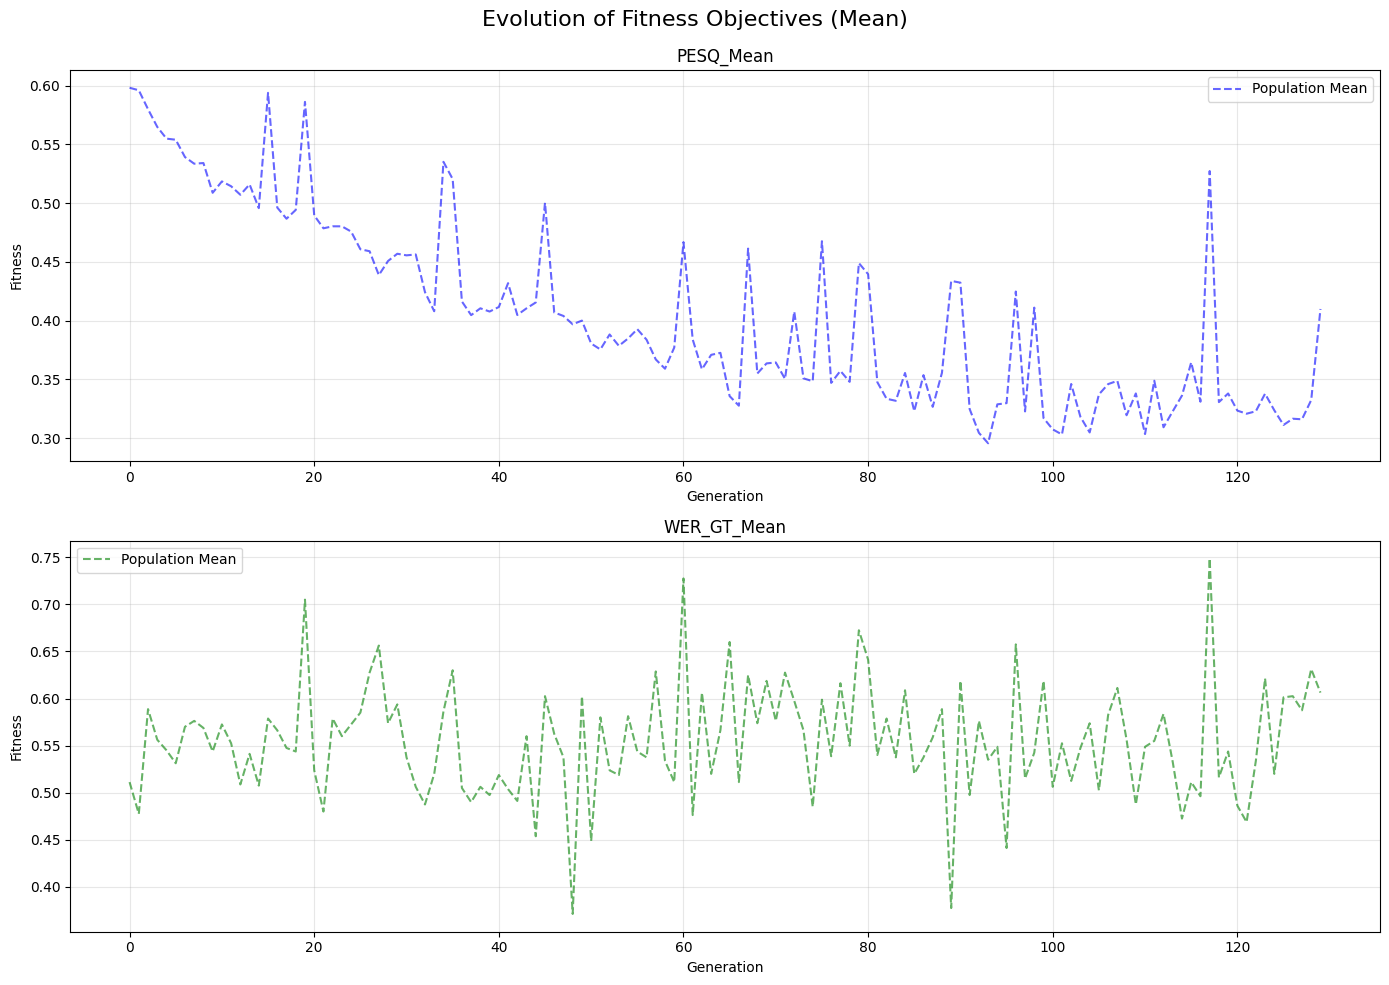

=== Synthesis of Best Candidate After Optimization ===
Best candidate fitness values:
  PESQ: 0.423154
  WER_GT: -26.625000

ASR Transcription of Best Candidate:
  "I think the NFL is lame and boring."
  ASR confidence (avg_logprob) = -0.7245500087738037

=== Ground-truth Audio ===


=== Target Audio ===


=== Best Mixed Candidate Audio ===


In [19]:
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")

# Use a stable order for folder naming (filtered OBJECTIVE_ORDER)
objective_tags = [
    obj.name for obj in OBJECTIVE_ORDER if obj in ACTIVE_OBJECTIVES
]
objectives_str = "_".join(objective_tags) if objective_tags else "NONE"

folder_path = os.path.join("outputs", "h_text", objectives_str, timestamp)
os.makedirs(folder_path, exist_ok=True)

##### Graph #####

# Convert the history list to a DataFrame
df_all_fitness = pd.DataFrame(fitness_history)

# Convert the mean tracking to a DataFrame (easier to plot later)
df_means = pd.DataFrame(mean_model)

# Grab all mean columns (e.g. 'UTMOS_Mean', 'WER_Mean', ...)
fitness_cols = [
    col for col in df_means.columns
    if col.endswith("_Mean") and col != "Generation"
]

# Optional pretty labels for the plots
name_map = {
    "UTMOS_Mean": "UTMOS (Quality Proxy, ↓ is worse here)",
    "WER_Mean": "WER (Word Error Rate)",
    "WAV2VEC_GT_Mean": "wav2vec (GT Similarity)",
    "WAV2VEC_TARGET_Mean": "wav2vec (Target Similarity)",
    "SBERT_GT_Mean": "S-BERT (GT Semantics)",
    "SBERT_TARGET_Mean": "S-BERT (Target Semantics)",
    "TEXT_EMB_GT_Mean": "Text Embedding (GT)",
    "TEXT_EMB_TARGET_Mean": "Text Embedding (Target)",
    "L1_Mean": "L1 Norm (Vector Magnitude)",
    "L2_Mean": "L2 Norm (Vector Magnitude)",
}

# Setup Plot
fig, axs = plt.subplots(len(fitness_cols), 1, figsize=(14, 5 * len(fitness_cols)))
if len(fitness_cols) == 1:
    axs = [axs]  # Handle single plot edge case

fig.suptitle("Evolution of Fitness Objectives (Mean)", fontsize=16)

# Loop through the existing columns
for j, col_name in enumerate(sorted(fitness_cols)):  # sorted for stable order, optional
    x_data = df_means["Generation"]
    y_data = df_means[col_name]

    plot_label = name_map.get(col_name, col_name)
    color = "blue" if j % 2 == 0 else "green"  # Alternate colors

    axs[j].plot(
        x_data,
        y_data,
        color=color,
        linestyle="--",
        alpha=0.6,
        label="Population Mean",
    )

    axs[j].set_title(plot_label)
    axs[j].set_xlabel("Generation")
    axs[j].set_ylabel("Fitness")
    axs[j].grid(True, alpha=0.3)
    axs[j].legend()

plt.tight_layout()
plt.subplots_adjust(top=0.92)  # Make room for suptitle
plt.savefig(os.path.join(folder_path, "graph.png"), dpi=300, bbox_inches="tight")
plt.show()


##### Best Candidate #####

print("=== Synthesis of Best Candidate After Optimization ===")

# 1) Get best candidate(s) from optimizer
best_candidates = optimizer.best_candidates
best = best_candidates[0]   # first Pareto-optimal candidate

# 2) Print FITNESS values dynamically in the same order used for optimization
active_in_order = [obj for obj in OBJECTIVE_ORDER if obj in ACTIVE_OBJECTIVES]

print("Best candidate fitness values:")
for obj, score in zip(active_in_order, best.fitness):
    print(f"  {obj.name}: {score:.6f}")
print()

# 3) Extract interpolation vector (flat), adjust to (1, C, T)
best_vector = torch.from_numpy(best.solution).to(device).float()
best_vector = best_vector.view(phoneme_count, size_per_phoneme)

# Let adjustInterpolationVector do the shape handling (flatten/view is done inside)
best_vector = adjustInterpolationVector(best_vector, random_matrix, size_per_phoneme)

# 4) Create mixed embeddings using the best vector
if mode is AttackMode.NOISE_UNTARGETED or mode is AttackMode.TARGETED:
    h_text_mixed_best = (1.0 - best_vector) * h_text_gt + best_vector * h_text_target
else:
    # match whatever formula you used inside the main loop for UNTARGETED
    # (right now your loop does: h_text_mixed = interpolation_vector + iv_scalar * interpolation_vector)
    h_text_mixed_best = best_vector + iv_scalar * best_vector

h_bert_mixed_best = h_bert_gt

# 5) Run TTS inference for:
#    - ground-truth
#    - target
#    - best mixed candidate
with torch.no_grad():
    audio_gt = tts_model.inference_after_interpolation(
        input_lengths,
        text_mask,
        h_bert_gt,
        h_text_gt,
        style_vector_acoustic,
        style_vector_prosodic,
    )

    audio_target = tts_model.inference_after_interpolation(
        input_lengths,
        text_mask,
        h_bert_target,
        h_text_target,
        style_vector_acoustic,
        style_vector_prosodic,
    )

    audio_best = tts_model.inference_after_interpolation(
        input_lengths,
        text_mask,
        h_bert_mixed_best,
        h_text_mixed_best,
        style_vector_acoustic,
        style_vector_prosodic,
    )

# 6) Run ASR on final audio and print predicted text
asr_final, conf_final = asr_model.analyzeAudio(audio_best)
predicted_text_final = asr_final["text"].strip()

print("ASR Transcription of Best Candidate:")
print(f'  "{predicted_text_final}"')
print(f"  ASR confidence (avg_logprob) = {conf_final}")
print()

# 7) Play all three audios: GT, target, and mixed best
print("=== Ground-truth Audio ===")
display(ipd.Audio(audio_gt, rate=24000))

print("=== Target Audio ===")
display(ipd.Audio(audio_target, rate=24000))

print("=== Best Mixed Candidate Audio ===")
display(ipd.Audio(audio_best, rate=24000))


#### Save Data ####

state_dict = {
    # The Core Result (converted to Tensor for immediate use next time)
    "interpolation_vector": torch.tensor(best.solution).float().cpu(),
    "random_matrix": random_matrix,
    "size_per_phoneme": size_per_phoneme,

    # Metadata (So you know how good it was)
    "fitness_values": best.fitness,
    "active_objectives": active_in_order,  # store ordered list for clarity

    # Configuration (Optional: Save text inputs so you can reproduce audio)
    "text_gt": text_gt,
    "text_target": text_target,
    "asr_text": predicted_text_final,
    "num_generations": num_generations,
    "population_size": pop_size,
    "noise": noise,
    "input_lengths": input_lengths,
    "text_mask": text_mask,
    "h_bert": h_bert_mixed_best,
    "h_text": h_text_mixed_best,

    # Generation info
    "generation_found": getattr(best, "generation", "Unknown"),
}

torch.save(state_dict, os.path.join(folder_path, "best_vector.pt"))

#### Write Text Summary ####

summary_path = os.path.join(folder_path, "run_summary.txt")

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("=== Adversarial TTS Optimization Summary ===\n\n")

    f.write(f"AttackMode: {mode}\n")

    f.write(f"Population size (pop_size): {pop_size}\n")
    f.write(f"Number of generations (generation_count): {num_generations}\n")
    f.write(f"Size per phoneme: {size_per_phoneme}\n")

    f.write(f"Generation best candidate found: {getattr(best, 'generation', 'Unknown')}\n\n")

    f.write("Final fitness values (best candidate):\n")
    if len(best.fitness) != len(active_in_order):
        f.write("  Warning: length mismatch between ACTIVE_OBJECTIVES and best.fitness.\n")
        f.write(f"  Raw fitness values: {best.fitness}\n")
    else:
        for obj, score in zip(active_in_order, best.fitness):
            score_float = float(score)
            f.write(f"  {obj.name}: {score_float:.6f}\n")

    f.write("\nASR transcription of best candidate:\n")
    f.write(f'  "{predicted_text_final}"\n')
    f.write(f"  ASR confidence (avg_logprob): {float(conf_final):.6f}\n")


#### Write Audio Files ####

sf.write(os.path.join(folder_path, "ground_truth.wav"), audio_gt, samplerate=24000)
sf.write(os.path.join(folder_path, "target.wav"), audio_target, samplerate=24000)
sf.write(os.path.join(folder_path, "interpolated.wav"), audio_best, samplerate=24000)


## Load from file

In [13]:
loading_folder_path = r"outputs\h_text\utmos_wer_wav2vec-gt\20251203_2124"

### Load .pt-file

In [14]:
# 1. Load the dictionary from the file
loaded_state_dict = torch.load(
    os.path.join(loading_folder_path, "best_vector.pt"),
    weights_only=False
)

# 2. Extract the variables back out
interpolation_vector = loaded_state_dict["interpolation_vector"].to(device).float()
# random_matrix = loaded_state_dict["random_matrix"].to(device).float()
# size_per_phoneme = loaded_state_dict["size_per_phoneme"].to(device).float()

# interpolation_vector = adjustInterpolationVector(interpolation_vector, random_matrix, size_per_phoneme)
#
# if mode is AttackMode.NOISE_UNTARGETED or mode is AttackMode.TARGETED:
#     h_text_mixed_best = (1.0 - interpolation_vector) * h_text_gt + interpolation_vector * h_text_target
# else:
#     h_text_mixed_best = h_text_gt + iv_scalar * interpolation_vector

fitness_values = loaded_state_dict["fitness_values"]
active_objectives = loaded_state_dict["active_objectives"]

# Extracting text data
text_gt = loaded_state_dict["text_gt"]
text_target = loaded_state_dict["text_target"]
asr_text = loaded_state_dict["asr_text"]

# Extracting metadata
generation_found = loaded_state_dict["generation_found"]

# Verification print
print(f"Loaded vector shape: {interpolation_vector.shape}")
# print(f"ASR Text: {asr_text}")
print(f"Fitness: {fitness_values}")

Loaded vector shape: torch.Size([424])
Fitness: [-3.38772416  0.2         0.02781457]


### Load .wav-file

In [15]:
import librosa
y, sr = librosa.load(os.path.join(loading_folder_path, "interpolated.wav"), sr=None) # sr=None keeps the original sample rate

asr_final, conf_final = asr_model.analyzeAudio(y)
predicted_text_final = asr_final["text"].strip()

print(f"ASR Transcription of Best Candidate: {predicted_text_final}")

ASR Transcription of Best Candidate: The Sun Holy Hawking are the best team.
